# NB5 — SVF Framework: Controlled Testing & Engine Failure Analysis

## What this notebook does

### Part 1 — Controlled Fault Testing
Runs the **complete 3-stage pipeline** on individual hand-crafted test windows:

```
Window → Stage 1 (AE): Nominal / Faulty?
              ↓ if Faulty
         Stage 2 (LSTM): Fault Type + Sensor ID + Magnitude
              ↓
         Stage 3: Virtual Sensor Accommodation + SHAP explanation
```

One test scenario per row in the results table.

### Part 2 — Real Engine Failure Analysis
Loads the failure CSV, extracts rows from the **failure zone (row ≥ 23000)**, and
runs **binary anomaly detection only** (AE Stage 1) to confirm the framework flags
the genuine failure event. Plots severity timeline and reconstruction error distributions.


In [1]:
import sys, os, pickle, warnings, logging, json
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')

import numpy as np
import matplotlib.pyplot as plt
import torch

sys.path.insert(0, '..')
from models import ConvAutoencoder, AETrainer, DEVICE

PROC_DIR = '../processed_data'
CKPT_DIR = '../checkpoints'
PLOT_DIR = '../plots'

print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

2026-04-23 15:41:10,422 [INFO] GPU: NVIDIA RTX 4500 Ada Generation


Device : cuda
GPU    : NVIDIA RTX 4500 Ada Generation


In [2]:
import sys, os, pickle, warnings, json, itertools
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

sys.path.insert(0, '..')
from models import (
    ConvAutoencoder, AETrainer,
    MultiHeadLSTM,
    MultiHeadTransformer,
    MCDropoutWrapper,
    DEVICE,
)
from fault_engine  import FaultEngine, FAULT_LABEL_TO_INT
from explainability import SHAPExplainer

PROC_DIR = '../processed_data'
CKPT_DIR = '../checkpoints'
PLOT_DIR = '../plots'

# Colour palette
NAVY  = '#1B2A4A'
STEEL = '#2E5B8A'
GOLD  = '#C9A84C'
RED   = '#C0392B'
GREEN = '#2E7D52'

label_names = {0:'Nominal', 1:'Bias', 2:'Scaling', 3:'Drift',
               4:'Intermittent', 5:'Compound', 6:'MultiSensor'}

print(f'Device : {DEVICE}')


2026-04-23 15:41:13,628 [INFO] NumExpr defaulting to 12 threads.


Device : cuda


## 0 — Load all artefacts

In [3]:
import pickle, json
import numpy as np, torch

with open(f'{PROC_DIR}/sensor_cols.pkl', 'rb') as f:
    sensor_cols = pickle.load(f)
with open(f'{CKPT_DIR}/nb3_meta.json') as f:
    meta = json.load(f)

N_SENSORS     = meta['n_sensors']       # 29
WINDOW_SIZE   = meta['window_size']     # 100
N_FAULT_TYPES = meta['n_fault_types']   # 7
USE_RESIDUAL  = meta['use_residual']

# ── Autoencoder ──────────────────────────────────────────────────────────────
ae_model = ConvAutoencoder(
    n_sensors=N_SENSORS, window_size=WINDOW_SIZE,
    base_ch=16, latent_dim=32, dropout_p=0.20
).to(DEVICE)
ae_model.load_state_dict(torch.load(f'{CKPT_DIR}/autoencoder.pt',
                                     map_location=DEVICE, weights_only=True))
ae_model.eval()
ae_trainer = AETrainer(ae_model, device=DEVICE)

# ── LSTM (best classifier) ───────────────────────────────────────────────────
cfg = meta['lstm_config']
lstm_model = MultiHeadLSTM(
    n_sensors     = N_SENSORS,
    hidden_size   = cfg['hidden_size'],
    num_layers    = cfg['num_layers'],
    n_fault_types = N_FAULT_TYPES,
    dropout_p     = cfg['dropout_p'],
    use_residual  = USE_RESIDUAL,
)
lstm_model.load_state_dict(torch.load(f'{CKPT_DIR}/lstm_multihead.pt',
                                        map_location=DEVICE, weights_only=True))
lstm_model.to(DEVICE).eval()
mc_lstm = MCDropoutWrapper(lstm_model, T=50)

# ── SHAP explainer (pre-built in NB4) ────────────────────────────────────────
with open(f'{CKPT_DIR}/shap_explainers.pkl', 'rb') as f:
    shap_explainers = pickle.load(f)
lstm_expl = shap_explainers.get('LSTM')

# ── Nominal windows for AE threshold & fault injection base ──────────────────
X_nominal = np.load(f'{PROC_DIR}/X_nominal.npy')   # (N, 100, 29)

# ── AE anomaly threshold (P95 of nominal reconstruction errors) ───────────────
BATCH = 256
nom_errors = np.zeros(len(X_nominal), dtype=np.float32)
for i in range(0, len(X_nominal), BATCH):
    xb = torch.from_numpy(X_nominal[i:i+BATCH].transpose(0,2,1)).float().to(DEVICE)
    with torch.no_grad():
        xhat, _ = ae_model(xb)
        err = (xb - xhat).abs().mean(dim=(1,2))
    nom_errors[i:i+BATCH] = err.cpu().numpy()

AE_THRESHOLD = float(np.percentile(nom_errors, 95))

# ── Global sensor range (needed for fault injection) ─────────────────────────
global_sensor_range = (X_nominal.reshape(-1, N_SENSORS).max(axis=0) -
                       X_nominal.reshape(-1, N_SENSORS).min(axis=0))

print(f'N_SENSORS    : {N_SENSORS}')
print(f'WINDOW_SIZE  : {WINDOW_SIZE}')
print(f'N_FAULT_TYPES: {N_FAULT_TYPES}')
print(f'AE threshold : {AE_THRESHOLD:.6f}  (P95 of {len(X_nominal):,} nominal windows)')
print(f'SHAP explainers available: {list(shap_explainers.keys())}')


2026-04-23 15:41:20,059 [INFO] AE Bottleneck: 1664 -> 32 -> 1664


N_SENSORS    : 29
WINDOW_SIZE  : 100
N_FAULT_TYPES: 7
AE threshold : 0.049481  (P95 of 16,022 nominal windows)
SHAP explainers available: ['ANN', 'LSTM', 'Transformer']


## 1 — SVF Pipeline Functions

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
#  STAGE 1 — AE Anomaly Detection
# ─────────────────────────────────────────────────────────────────────────────
def stage1_ae(window: np.ndarray) -> dict:
    """
    Args:
        window : (100, 29) float32 — single sensor window
    Returns:
        dict with keys: is_anomaly, recon_error, severity_pct, x_recon
    """
    xb = torch.from_numpy(window.T[np.newaxis]).float().to(DEVICE)  # (1, 29, 100)
    with torch.no_grad():
        xhat, _ = ae_model(xb)
        err = (xb - xhat).abs().mean().item()
    x_recon = xhat.squeeze(0).T.cpu().numpy()   # back to (100, 29)
    severity = min(100.0, err / (5 * nom_errors.mean()) * 100)
    return {
        'is_anomaly'   : err > AE_THRESHOLD,
        'recon_error'  : err,
        'severity_pct' : severity,
        'x_recon'      : x_recon,
        'threshold'    : AE_THRESHOLD,
    }


# ─────────────────────────────────────────────────────────────────────────────
#  STAGE 2 — LSTM Classification
# ─────────────────────────────────────────────────────────────────────────────
def stage2_lstm(window: np.ndarray, x_recon: np.ndarray) -> dict:
    """
    Args:
        window  : (100, 29) raw sensor window
        x_recon : (100, 29) AE reconstruction
    Returns:
        dict with fault_type, fault_name, sensor_idx, sensor_name,
              magnitude, confidence, confidence_std
    """
    if USE_RESIDUAL:
        x_inp = np.concatenate([window, np.abs(window - x_recon)], axis=-1)  # (100, 58)
    else:
        x_inp = window
    xt = torch.from_numpy(x_inp[np.newaxis]).float().to(DEVICE)  # (1, 100, 58/29)

    res_fault = mc_lstm.predict(xt, head='fault')
    res_mag   = mc_lstm.predict(xt, head='magnitude')

    # Sensor head (no MC needed)
    lstm_model.eval()
    with torch.no_grad():
        lf, ls, lm = lstm_model(xt)
    sensor_idx  = int(ls.argmax(dim=1).item())
    fault_type  = int(res_fault['pred_class'].item())
    magnitude   = float(res_mag['mean_mag'].item())
    confidence  = float(res_fault['confidence'].item())
    # conf_std    = float(res_fault['std_proba'].item())

    return {
        'fault_type'    : fault_type,
        'fault_name'    : label_names.get(fault_type, str(fault_type)),
        'sensor_idx'    : sensor_idx,
        'sensor_name'   : sensor_cols[sensor_idx] if sensor_idx < len(sensor_cols) else f'A{sensor_idx}',
        'magnitude'     : magnitude,
        'confidence'    : confidence,
        # 'confidence_std': conf_std,
        'fault_probs'   : res_fault['mean_proba'].cpu().numpy().squeeze(),
    }


# ─────────────────────────────────────────────────────────────────────────────
#  STAGE 3 — Virtual Sensor Accommodation + SHAP
# ─────────────────────────────────────────────────────────────────────────────
def stage3_accommodate(window: np.ndarray, x_recon: np.ndarray,
                        sensor_idx: int) -> np.ndarray:
    """Replace faulty channel with AE reconstruction."""
    accommodated          = window.copy()
    accommodated[:, sensor_idx] = x_recon[:, sensor_idx]
    return accommodated


def stage3_shap(window: np.ndarray, x_recon: np.ndarray,
                fault_class: int) -> dict:
    """GradientSHAP explanation for a single window."""
    if lstm_expl is None:
        return {'top_sensors': [], 'sensor_importance': np.zeros(N_SENSORS)}
    expl_obj, _ = lstm_expl  # SHAPExplainer instance

    if USE_RESIDUAL:
        x_inp = np.concatenate([window, np.abs(window - x_recon)], axis=-1)
    else:
        x_inp = window

    sv, _ = expl_obj.explain(x_inp[np.newaxis], top_k=5, class_idx=fault_class)
    # sv shape: (1, T, S_inp) — take only raw sensor channels
    sv_raw = sv[0, :, :N_SENSORS]                  # (T, 29)
    sen_imp = np.abs(sv_raw).sum(axis=0)            # (29,)
    top_idx = np.argsort(sen_imp)[::-1][:5]
    top_sensors = [(sensor_cols[i] if i < len(sensor_cols) else f'A{i}',
                    float(sen_imp[i])) for i in top_idx]
    return {
        'top_sensors'       : top_sensors,
        'sensor_importance' : sen_imp,
        'sv_raw'            : sv_raw,
    }


print('Pipeline functions defined: stage1_ae | stage2_lstm | stage3_accommodate | stage3_shap')


Pipeline functions defined: stage1_ae | stage2_lstm | stage3_accommodate | stage3_shap


## 2 — Full Pipeline Runner

In [5]:
def run_svf_pipeline(window: np.ndarray,
                     scenario_name: str = '',
                     true_label: int = None,
                     run_shap: bool = True,
                     plot: bool = True) -> dict:
    """
    Run the complete SVF pipeline on a single window.

    Args:
        window        : (100, 29) float32 sensor window
        scenario_name : Label for display
        true_label    : Ground truth class index (optional, for display)
        run_shap      : Whether to run SHAP (slower)
        plot          : Whether to generate the per-scenario plot

    Returns:
        Full result dict containing all stage outputs.
    """
    print(f'\n{"="*62}')
    print(f'  Scenario: {scenario_name}')
    if true_label is not None:
        print(f'  True label: {label_names.get(true_label, str(true_label))}')
    print(f'{"="*62}')

    # ── Stage 1 ───────────────────────────────────────────────────────────────
    s1 = stage1_ae(window)
    print(f'  Stage 1 — AE Anomaly Detection')
    print(f'    Reconstruction error : {s1["recon_error"]:.6f}')
    print(f'    Threshold            : {s1["threshold"]:.6f}')
    print(f'    Severity             : {s1["severity_pct"]:.1f}%')
    print(f'    Decision             : {"⚠ FAULTY" if s1["is_anomaly"] else "✓ NOMINAL"}')

    result = {'scenario': scenario_name, 'true_label': true_label,
              'stage1': s1, 'stage2': None, 'stage3_shap': None,
              'accommodated': None}

    if not s1['is_anomaly']:
        print(f'  → Framework stops: window classified as NOMINAL.')
        if plot:
            _plot_nominal_result(window, s1, scenario_name)
        return result

    # ── Stage 2 ───────────────────────────────────────────────────────────────
    s2 = stage2_lstm(window, s1['x_recon'])
    result['stage2'] = s2
    print(f'  Stage 2 — LSTM Classification')
    print(f'    Fault type  : {s2["fault_name"]} (class {s2["fault_type"]})')
    print(f'    Sensor ID   : {s2["sensor_name"]} (idx {s2["sensor_idx"]})')
    print(f'    Magnitude   : {s2["magnitude"]:.4f}')
    print(f'    Confidence  : {s2["confidence"]:.4f}') # ± {s2["confidence_std"]:.4f}

    # ── Stage 3a — Virtual Sensor ─────────────────────────────────────────────
    accommodated = stage3_accommodate(window, s1['x_recon'], s2['sensor_idx'])
    result['accommodated'] = accommodated
    print(f'  Stage 3 — Virtual Sensor Accommodation')
    print(f'    Channel {s2["sensor_name"]} replaced with AE reconstruction.')
    delta = np.abs(window[:, s2['sensor_idx']] - accommodated[:, s2['sensor_idx']]).mean()
    print(f'    Mean delta (raw vs accommodated): {delta:.6f}')

    # ── Stage 3b — SHAP ───────────────────────────────────────────────────────
    shap_result = None
    if run_shap:
        try:
            shap_result = stage3_shap(window, s1['x_recon'], s2['fault_type'])
            result['stage3_shap'] = shap_result
            print(f'  SHAP — Top sensors driving prediction:')
            for sname, imp in shap_result['top_sensors']:
                bar = '█' * int(imp / max(shap_result['sensor_importance']) * 20)
                print(f'    {sname:>6}: {bar:<20} {imp:.4f}')
        except Exception as e:
            print(f'  SHAP skipped: {e}')

    # ── Plot ──────────────────────────────────────────────────────────────────
    if plot:
        _plot_full_result(window, s1, s2, shap_result, accommodated,
                          scenario_name, true_label)
    return result


# ─── Plotting helpers ─────────────────────────────────────────────────────────
def _plot_nominal_result(window, s1, name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'SVF — {name}  |  Stage 1: NOMINAL (no fault)', fontsize=12,
                 fontweight='bold', color=GREEN)

    # Signal overview
    ax = axes[0]
    for si in range(min(6, N_SENSORS)):
        ax.plot(window[:, si], lw=1, alpha=0.7, label=sensor_cols[si])
    ax.set_title('Input window (first 6 sensors)'); ax.set_xlabel('Timestep')
    ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

    # Reconstruction error bar
    ax2 = axes[1]
    ax2.bar(['Recon Error'], [s1['recon_error']], color=STEEL, width=0.4)
    ax2.axhline(s1['threshold'], color=GOLD, lw=2, ls='--',
                label=f'Threshold ({s1["threshold"]:.5f})')
    ax2.set_title('Stage 1 — AE Reconstruction Error')
    ax2.set_ylim(0, s1['threshold'] * 2)
    ax2.legend(); ax2.grid(axis='y', alpha=0.3)
    ax2.text(0, s1['recon_error'] + 0.0001, f'{s1["recon_error"]:.5f}',
             ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/nb5_scenario_{name.replace(" ","_")}.png', dpi=120,
                bbox_inches='tight')
    plt.show()


def _plot_full_result(window, s1, s2, shap_res, accommodated, name, true_label):
    has_shap = shap_res is not None and len(shap_res['top_sensors']) > 0
    ncols = 4 if has_shap else 3
    fig, axes = plt.subplots(1, ncols, figsize=(5.5*ncols, 5))

    correct = (true_label is not None) and (true_label == s2['fault_type'])
    hdr_col = GREEN if correct else (RED if true_label is not None else STEEL)
    true_str = f'  True: {label_names.get(true_label,"?")}' if true_label is not None else ''
    fig.suptitle(
        f'SVF — {name}{true_str}  |  '
        f'Predicted: {s2["fault_name"]}  |  '
        f'Sensor: {s2["sensor_name"]}  |  '
        f'Confidence: {s2["confidence"]:.2f}',
        fontsize=11, fontweight='bold', color=hdr_col
    )

    # Panel 1: raw vs reconstruction on predicted faulty sensor
    ax = axes[0]
    si = s2['sensor_idx']
    ax.plot(window[:, si], color=RED, lw=1.5, label='Raw (faulty)')
    ax.plot(s1['x_recon'][:, si], color=STEEL, lw=1.5, ls='--', label='AE Recon')
    ax.set_title(f'Stage 1 — Sensor {s2["sensor_name"]}\nRaw vs AE Reconstruction')
    ax.set_xlabel('Timestep'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # Panel 2: virtual sensor accommodation
    ax2 = axes[1]
    ax2.plot(window[:, si],        color=RED,   lw=1.5, alpha=0.7, label='Faulty (raw)')
    ax2.plot(s1['x_recon'][:, si], color=STEEL, lw=1.5, ls='--',  label='AE Recon')
    ax2.plot(accommodated[:, si],  color=GREEN, lw=2.0,            label='Accommodated ✓')
    ax2.set_title(f'Stage 3 — Virtual Sensor\n{s2["sensor_name"]} Accommodation')
    ax2.set_xlabel('Timestep'); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

    # Panel 3: fault type probability bar
    ax3 = axes[2]
    probs = s2['fault_probs']
    cnames = [label_names.get(i, str(i)) for i in range(N_FAULT_TYPES)]
    bars = ax3.barh(cnames, probs,
                    color=[GREEN if i==s2['fault_type'] else '#BBBBBB'
                           for i in range(N_FAULT_TYPES)])
    ax3.set_xlim(0, 1); ax3.set_xlabel('Probability')
    ax3.set_title(f'Stage 2 — Fault Type Probabilities\n'
                  f'MC Conf: {s2["confidence"]:.3f} ') #± {s2["confidence_std"]:.3f}
    ax3.axvline(0.5, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax3.grid(axis='x', alpha=0.3)
    for bar, p in zip(bars, probs):
        if p > 0.02:
            ax3.text(p+0.01, bar.get_y()+bar.get_height()/2,
                     f'{p:.2f}', va='center', fontsize=8)

    # Panel 4: SHAP sensor importance (if available)
    if has_shap:
        ax4 = axes[3]
        imp  = shap_res['sensor_importance']
        sidx = np.argsort(imp)[::-1][:10]
        snames_top = [sensor_cols[i] if i<len(sensor_cols) else f'A{i}' for i in sidx]
        cols_ = [GOLD if i==si else STEEL for i in sidx]
        ax4.barh(snames_top[::-1], imp[sidx][::-1], color=cols_[::-1])
        ax4.set_xlabel('Mean |SHAP|')
        ax4.set_title('Stage 3 — SHAP Sensor Importance\n(gold = predicted faulty sensor)')
        ax4.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/nb5_scenario_{name.replace(" ","_")}.png', dpi=120,
                bbox_inches='tight')
    plt.show()


print('Pipeline runner and plotting functions ready.')


Pipeline runner and plotting functions ready.


## 3 — Controlled Test Scenarios

Each test scenario:
1. Takes a real nominal window from `X_nominal`
2. Injects a specific fault type (or leaves it nominal)
3. Runs the full SVF pipeline
4. Prints and plots the result

Adjust `BASE_IDX` to change which nominal window is used as the base.


In [9]:
# ── Fault injection engine ────────────────────────────────────────────────────
engine = FaultEngine(seed=999, global_sensor_range=global_sensor_range)

# ── Pick a nominal base window ────────────────────────────────────────────────
BASE_IDX = 42   # ← change this to test different nominal windows
base_win = X_nominal[BASE_IDX].copy()   # (100, 29)

# ── Build test scenarios ──────────────────────────────────────────────────────
# Each entry: (scenario_name, window, true_class_idx)
test_scenarios = []

# Scenario 0: Pure Nominal
test_scenarios.append(('Scenario 0 — Nominal', base_win.copy(), 0))

# Scenario 1: Bias
w, si, lbl, _, mag = engine.inject_single_sensor_single_fault(base_win.copy(), fault_type='bias')
test_scenarios.append((f'Scenario 1 — Bias (sensor {sensor_cols[si] if si<len(sensor_cols) else si}, mag={mag:.3f})', w, lbl))

# Scenario 2: Scaling
w, si, lbl, _, mag = engine.inject_single_sensor_single_fault(base_win.copy(), fault_type='scaling', magnitude=3.0)
test_scenarios.append((f'Scenario 2 — Scaling (sensor {sensor_cols[si] if si<len(sensor_cols) else si}, mag={mag:.3f})', w, lbl))

# Scenario 3: Drift
w, si, lbl, _, mag = engine.inject_single_sensor_single_fault(base_win.copy(), fault_type='drift', magnitude=1.5)
test_scenarios.append((f'Scenario 3 — Drift (sensor {sensor_cols[si] if si<len(sensor_cols) else si}, mag={mag:.3f})', w, lbl))

# Scenario 4: Intermittent
w, si, lbl, _, mag = engine.inject_single_sensor_single_fault(base_win.copy(), fault_type='intermittent', magnitude=3)
test_scenarios.append((f'Scenario 4 — Intermittent (sensor {sensor_cols[si] if si<len(sensor_cols) else si}, mag={mag:.3f})', w, lbl))

# Scenario 5: Compound
w, si, lbl, seq = engine.inject_compound_fault(base_win.copy())
test_scenarios.append((f'Scenario 5 — Compound (sensor {sensor_cols[si] if si<len(sensor_cols) else si})', w, lbl))

# Scenario 6: MultiSensor
w, specs = engine.inject_multi_sensor_faults(base_win.copy())
sensors_str = '+'.join(sensor_cols[s.sensor_idx] if s.sensor_idx<len(sensor_cols) else f'A{s.sensor_idx}' for s in specs)
test_scenarios.append((f'Scenario 6 — MultiSensor ({sensors_str})', w, FAULT_LABEL_TO_INT['MultiSensor']))

print(f'{len(test_scenarios)} test scenarios ready:')
for i, (name, _, true_lbl) in enumerate(test_scenarios):
    print(f'  [{i}] {name}  (true={label_names.get(true_lbl, str(true_lbl))})')


2026-04-23 15:45:33,727 [INFO] FaultEngine initialized (seed=999) | mag_range=[0.60, 1.80] | interm_range=[0.80, 2.00] | global_range provided=True


7 test scenarios ready:
  [0] Scenario 0 — Nominal  (true=Nominal)
  [1] Scenario 1 — Bias (sensor A24, mag=0.807)  (true=Bias)
  [2] Scenario 2 — Scaling (sensor A23, mag=3.000)  (true=Scaling)
  [3] Scenario 3 — Drift (sensor A5, mag=1.500)  (true=Drift)
  [4] Scenario 4 — Intermittent (sensor A5, mag=3.000)  (true=Intermittent)
  [5] Scenario 5 — Compound (sensor A18)  (true=Compound)
  [6] Scenario 6 — MultiSensor (A4+A6)  (true=MultiSensor)


## 4 — Run All Controlled Scenarios


  Scenario: Scenario 0 — Nominal
  True label: Nominal
  Stage 1 — AE Anomaly Detection
    Reconstruction error : 0.027872
    Threshold            : 0.049481
    Severity             : 19.8%
    Decision             : ✓ NOMINAL
  → Framework stops: window classified as NOMINAL.


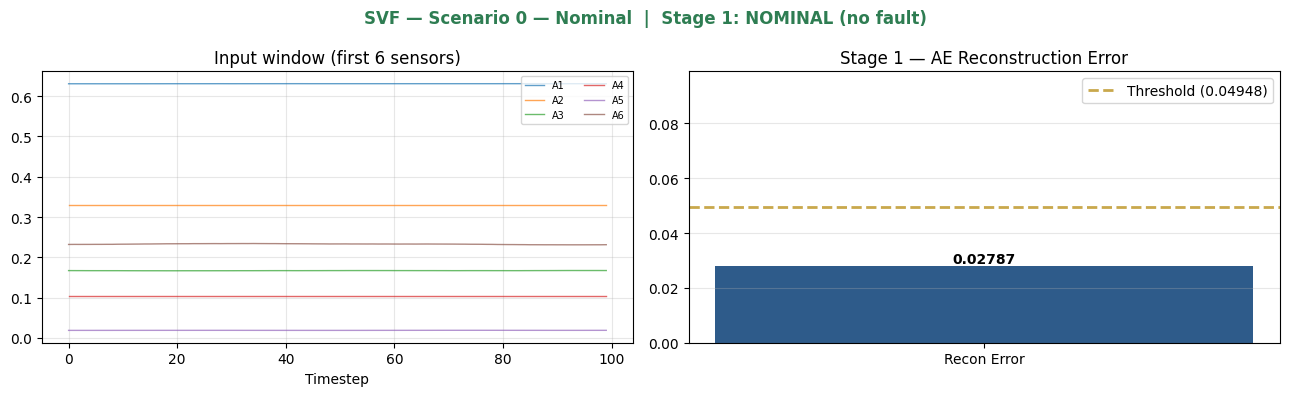


  Scenario: Scenario 1 — Bias (sensor A24, mag=0.807)
  True label: Bias
  Stage 1 — AE Anomaly Detection
    Reconstruction error : 0.053915
    Threshold            : 0.049481
    Severity             : 38.2%
    Decision             : ⚠ FAULTY
  Stage 2 — LSTM Classification
    Fault type  : Bias (class 1)
    Sensor ID   : A24 (idx 23)
    Magnitude   : 0.9796
    Confidence  : 0.9581
  Stage 3 — Virtual Sensor Accommodation
    Channel A24 replaced with AE reconstruction.
    Mean delta (raw vs accommodated): 0.542700
  SHAP — Top sensors driving prediction:
       A20: ████████████████████ 3.3179
       A14: ███████████████      2.5681
        A2: █████████████        2.1986
       A23: ████████████         2.0881
        A8: ███████████          1.9007


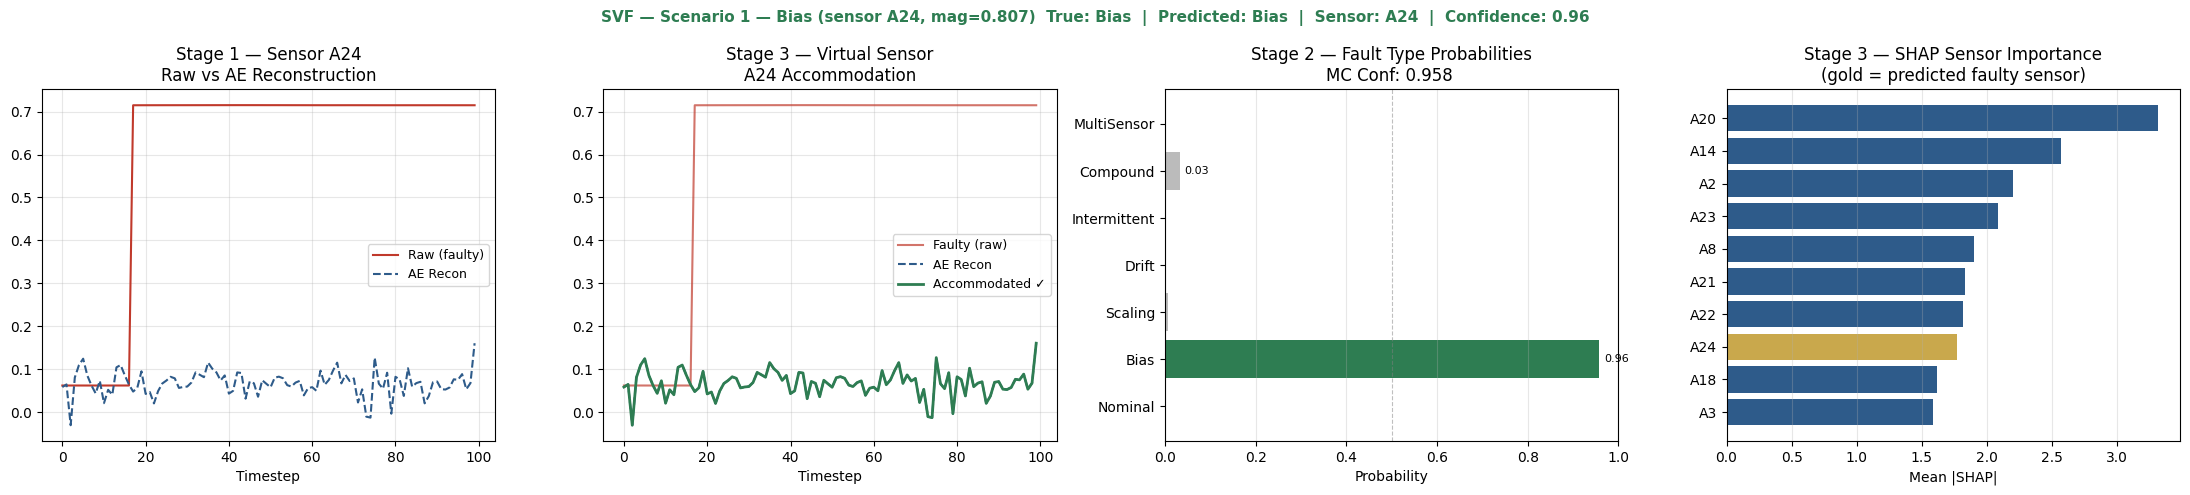


  Scenario: Scenario 2 — Scaling (sensor A23, mag=3.000)
  True label: Scaling
  Stage 1 — AE Anomaly Detection
    Reconstruction error : 0.058134
    Threshold            : 0.049481
    Severity             : 41.2%
    Decision             : ⚠ FAULTY
  Stage 2 — LSTM Classification
    Fault type  : Bias (class 1)
    Sensor ID   : A23 (idx 22)
    Magnitude   : 0.8834
    Confidence  : 0.9573
  Stage 3 — Virtual Sensor Accommodation
    Channel A23 replaced with AE reconstruction.
    Mean delta (raw vs accommodated): 0.379835
  SHAP — Top sensors driving prediction:
       A23: ████████████████████ 3.2216
        A8: ███████████████████  3.1797
       A29: █████████████████    2.8521
       A14: ████████████████     2.6258
       A27: ██████████████       2.3450


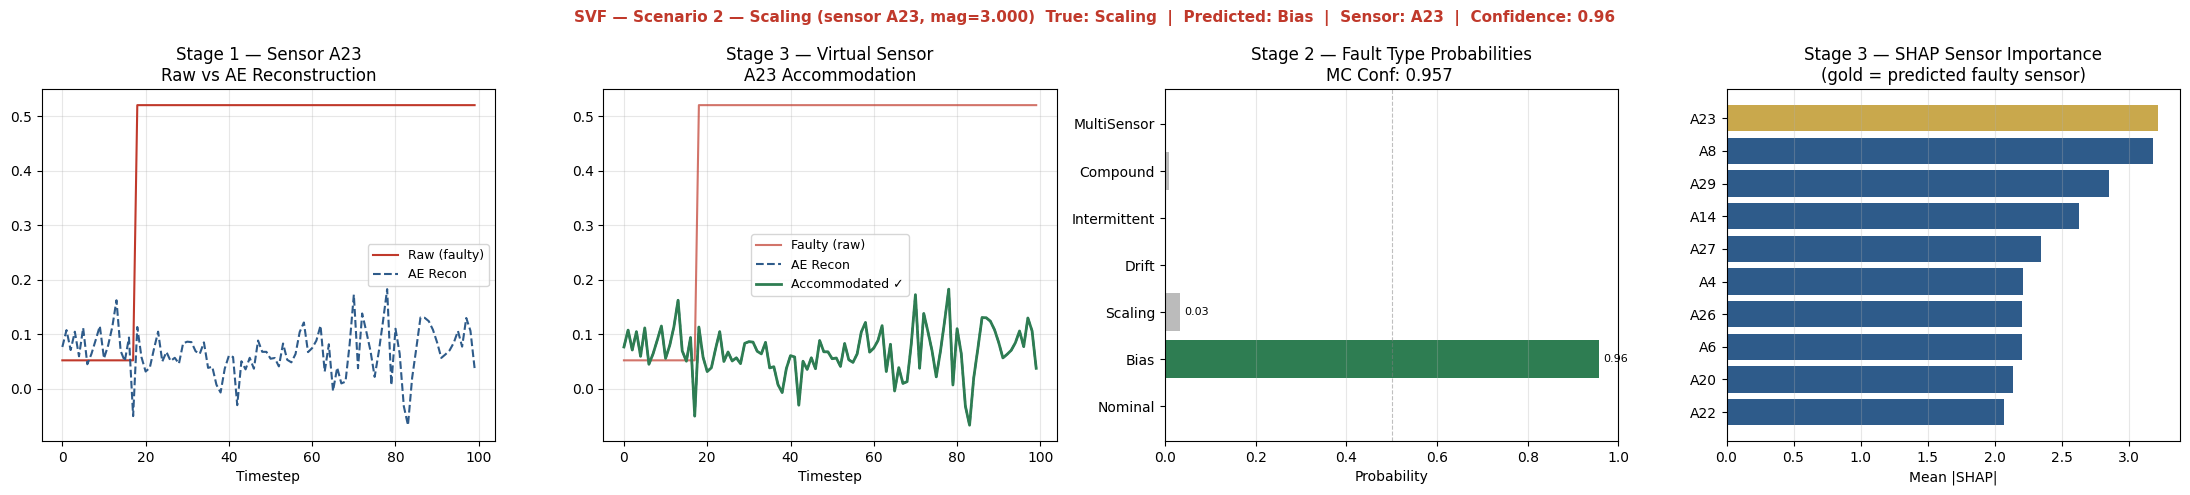


  Scenario: Scenario 3 — Drift (sensor A5, mag=1.500)
  True label: Drift
  Stage 1 — AE Anomaly Detection
    Reconstruction error : 0.053950
    Threshold            : 0.049481
    Severity             : 38.2%
    Decision             : ⚠ FAULTY
  Stage 2 — LSTM Classification
    Fault type  : Drift (class 3)
    Sensor ID   : A5 (idx 4)
    Magnitude   : 1.4111
    Confidence  : 0.9726
  Stage 3 — Virtual Sensor Accommodation
    Channel A5 replaced with AE reconstruction.
    Mean delta (raw vs accommodated): 0.603377
  SHAP — Top sensors driving prediction:
        A5: ████████████████████ 11.3824
        A8: ████                 2.5414
       A26: ███                  2.2388
       A15: ███                  2.2216
        A2: ███                  2.2177


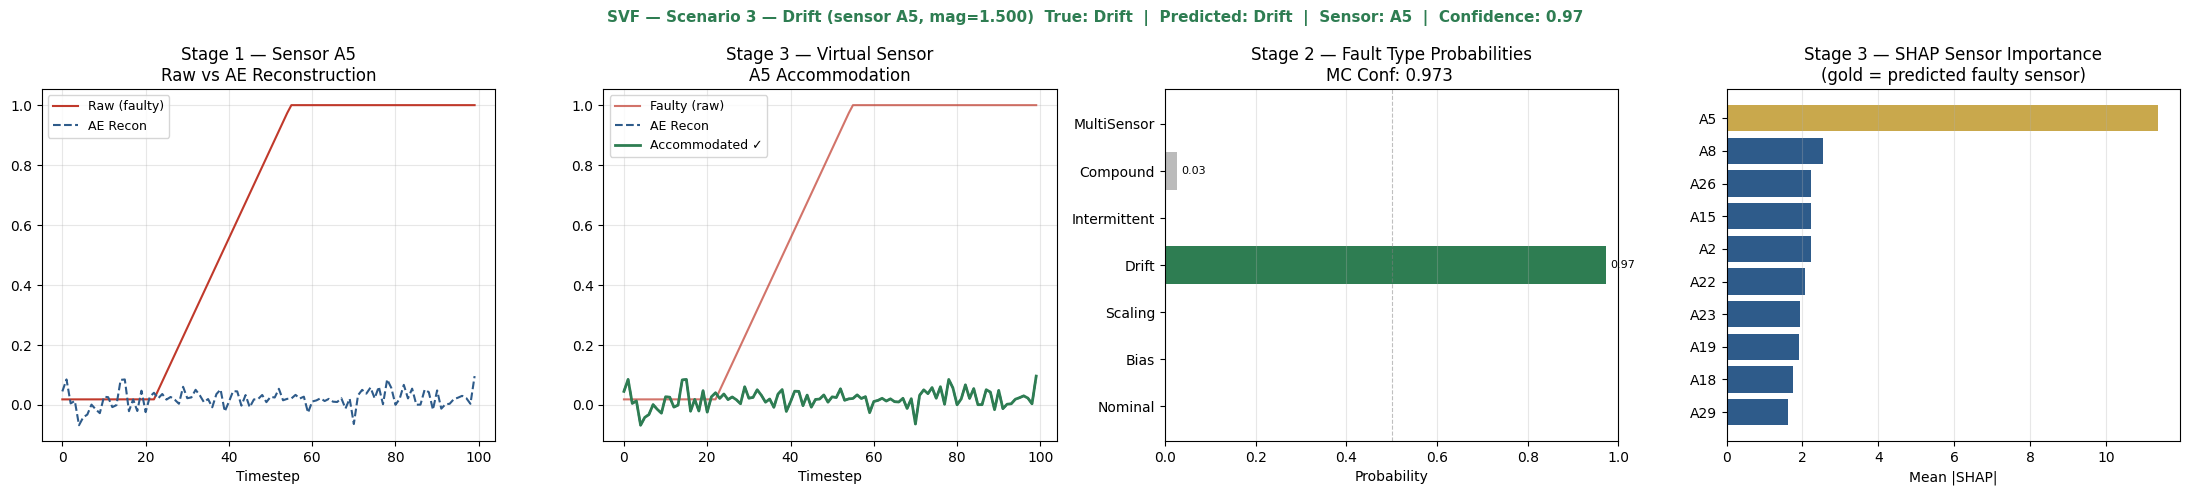


  Scenario: Scenario 4 — Intermittent (sensor A5, mag=3.000)
  True label: Intermittent
  Stage 1 — AE Anomaly Detection
    Reconstruction error : 0.031685
    Threshold            : 0.049481
    Severity             : 22.5%
    Decision             : ✓ NOMINAL
  → Framework stops: window classified as NOMINAL.


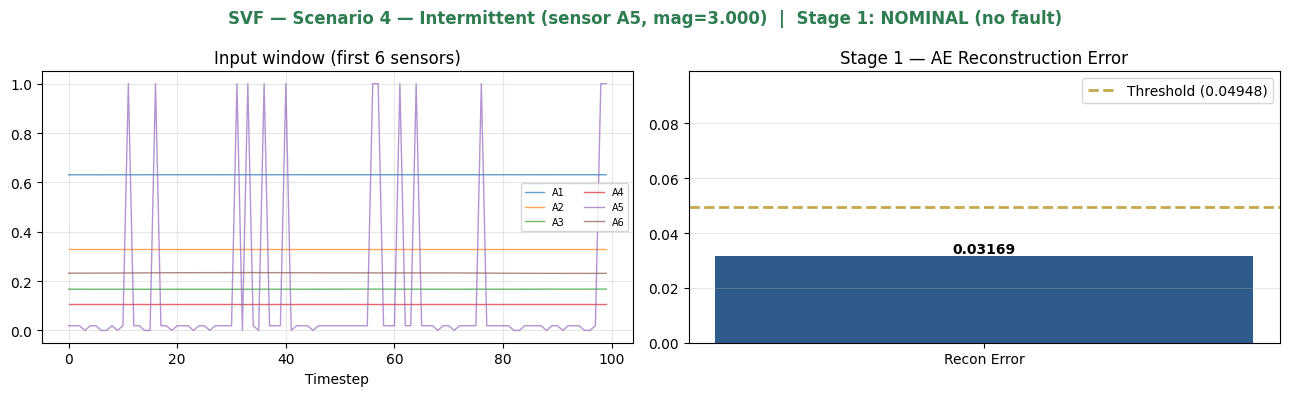


  Scenario: Scenario 5 — Compound (sensor A18)
  True label: Compound
  Stage 1 — AE Anomaly Detection
    Reconstruction error : 0.061706
    Threshold            : 0.049481
    Severity             : 43.7%
    Decision             : ⚠ FAULTY
  Stage 2 — LSTM Classification
    Fault type  : Compound (class 5)
    Sensor ID   : A18 (idx 17)
    Magnitude   : 1.3180
    Confidence  : 0.9946
  Stage 3 — Virtual Sensor Accommodation
    Channel A18 replaced with AE reconstruction.
    Mean delta (raw vs accommodated): 0.555226
  SHAP — Top sensors driving prediction:
       A18: ████████████████████ 4.4436
        A8: ████████████████     3.7436
       A26: ███████████          2.6026
       A23: ███████████          2.5536
       A24: █████████            2.1353


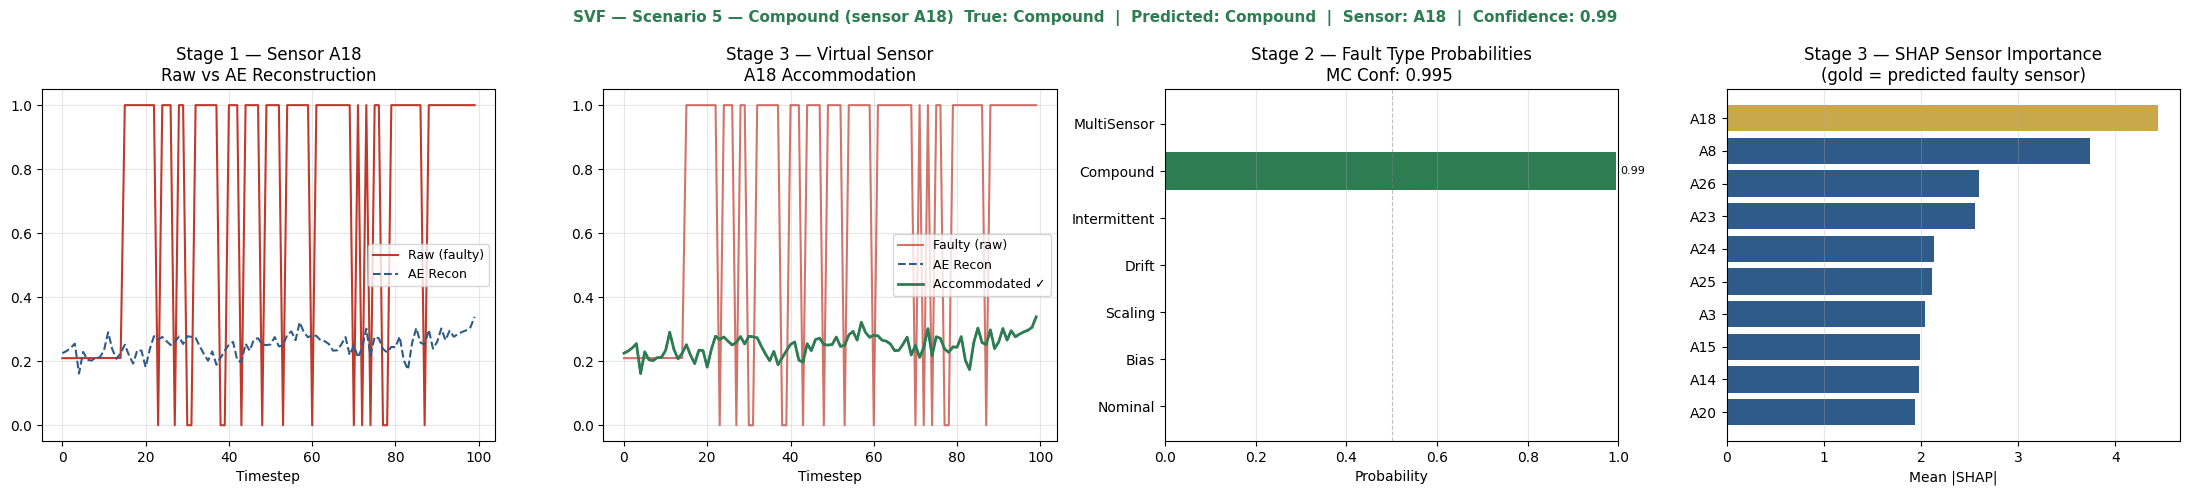


  Scenario: Scenario 6 — MultiSensor (A4+A6)
  True label: MultiSensor
  Stage 1 — AE Anomaly Detection
    Reconstruction error : 0.103345
    Threshold            : 0.049481
    Severity             : 73.2%
    Decision             : ⚠ FAULTY
  Stage 2 — LSTM Classification
    Fault type  : MultiSensor (class 6)
    Sensor ID   : A6 (idx 5)
    Magnitude   : 1.2885
    Confidence  : 0.9938
  Stage 3 — Virtual Sensor Accommodation
    Channel A6 replaced with AE reconstruction.
    Mean delta (raw vs accommodated): 0.531142
  SHAP — Top sensors driving prediction:
        A4: ████████████████████ 4.8317
       A25: ████████████████     3.9639
       A15: █████████████        3.2692
        A6: ███████████          2.7613
        A5: █████████            2.3218


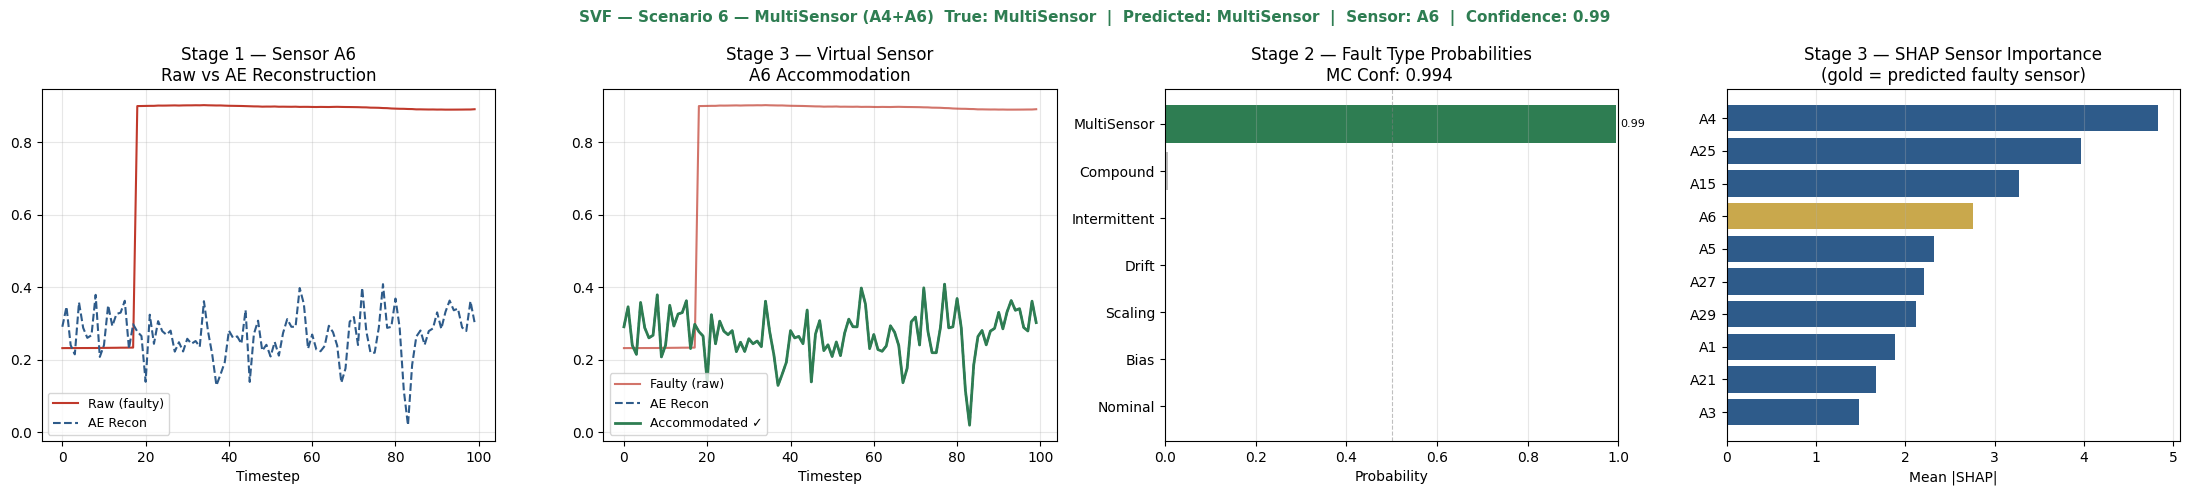


✓ All controlled scenarios complete.


In [10]:
# Set RUN_SHAP=False to skip SHAP and run faster during initial testing
RUN_SHAP = True

all_results = []
for name, window, true_lbl in test_scenarios:
    result = run_svf_pipeline(
        window        = window,
        scenario_name = name,
        true_label    = true_lbl,
        run_shap      = RUN_SHAP,
        plot          = True,
    )
    all_results.append(result)

print('\n✓ All controlled scenarios complete.')


## 5 — Controlled Test Results Summary Table

In [12]:
print()
print('╔' + '═'*90 + '╗')
print(f'║  {"SVF CONTROLLED TEST RESULTS":^88}  ')
print('╠' + '═'*90 + '╣')
print(f'║  {"Scenario":<30} {"True":>12} {"AE":>8} {"Pred Fault":>14} '
      f'{"Sensor":>8} {"Conf":>6}  ║')
print('╠' + '═'*90 + '╣')

correct_ae = 0; correct_clf = 0; total_faulty = 0

for r in all_results:
    s1  = r['stage1']
    s2  = r['stage2']
    name_short = r['scenario'][:30]
    true_name  = label_names.get(r['true_label'], '?')[:12] if r['true_label'] is not None else '?'
    ae_decision = 'FAULTY' if s1['is_anomaly'] else 'NOMINAL'

    # AE correctness
    ae_correct = (r['true_label'] == 0 and not s1['is_anomaly']) or \
                 (r['true_label'] != 0 and s1['is_anomaly'])
    if ae_correct:
        correct_ae += 1

    if r['true_label'] != 0:
        total_faulty += 1

    if s2 is not None:
        pred_name  = s2['fault_name'][:14]
        sensor_name = s2['sensor_name'][:8]
        conf_str   = f'{s2["confidence"]:.2f}'
        clf_correct = (r['true_label'] == s2['fault_type'])
        if clf_correct and r['true_label'] != 0:
            correct_clf += 1
        # tick = '✓' if clf_correct else '✗'
        print(f'║  {name_short:<30} {true_name:>12} {ae_decision:>8} '
              f'{pred_name:>13} {sensor_name:>8} {conf_str:>6}  ║')
    else:
        # ae_tick = '✓' if ae_correct else '✗'
        print(f'║  {name_short:<30} {true_name:>12} {ae_decision:>8} '
              f'{"—":>14} {"—":>8} {"—":>6}  ║')

print('╠' + '═'*90 + '╣')
n = len(all_results)
print(f'║  AE Detection Accuracy   : {correct_ae}/{n} ({correct_ae/n*100:.1f}%){" ":>60}')
if total_faulty > 0:
    print(f'║  Classification Accuracy : {correct_clf}/{total_faulty} '
          f'({correct_clf/total_faulty*100:.1f}% on faulty scenarios){" ":>43}')
print('╚' + '═'*90 + '╝')



╔══════════════════════════════════════════════════════════════════════════════════════════╗
║                                SVF CONTROLLED TEST RESULTS                                 
╠══════════════════════════════════════════════════════════════════════════════════════════╣
║  Scenario                               True       AE     Pred Fault   Sensor   Conf  ║
╠══════════════════════════════════════════════════════════════════════════════════════════╣
║  Scenario 0 — Nominal                Nominal  NOMINAL              —        —      —  ║
║  Scenario 1 — Bias (sensor A24,         Bias   FAULTY          Bias      A24   0.96  ║
║  Scenario 2 — Scaling (sensor A      Scaling   FAULTY          Bias      A23   0.96  ║
║  Scenario 3 — Drift (sensor A5,        Drift   FAULTY         Drift       A5   0.97  ║
║  Scenario 4 — Intermittent (sen Intermittent  NOMINAL              —        —      —  ║
║  Scenario 5 — Compound (sensor      Compound   FAULTY      Compound      A18   0.99  ║


---

## PART 2 — Real Engine Failure Analysis

The failure CSV contains a genuine engine failure event starting at approximately **row 23,000**.
We extract:
- **Pre-failure zone** (rows 0–22,999): expected to be nominal → AE should flag as normal
- **Failure zone** (rows 23,000–end): genuine failure → AE should flag as anomalous

This is **binary detection only** (Nominal vs Anomaly) — no classifier or SHAP needed.


## 6 — Load Failure CSV and Extract Zones

In [13]:
import pandas as pd

# ── Update this path to your failure CSV ──────────────────────────────────────
FAILURE_CSV    = '../data/lab//EngineFault/1682_Binary_Data_Dump_1.csv'   # ← update path
FAILURE_ONSET  = 22400                                   # ← confirmed failure onset row

df_fail = pd.read_csv(FAILURE_CSV)
print(f'Failure CSV shape: {df_fail.shape}')
print(f'Columns: {list(df_fail.columns[:10])} ...')

# Use the same sensor columns as the trained models
# If column names differ, map them here
available_cols = [c for c in sensor_cols if c in df_fail.columns]
if len(available_cols) == 0:
    # Fall back: use first N_SENSORS numeric columns
    num_cols = df_fail.select_dtypes(include=[np.number]).columns.tolist()
    available_cols = num_cols[:N_SENSORS]
    print(f'Warning: sensor_cols not found — using first {N_SENSORS} numeric columns.')

signal_full = df_fail[available_cols].values.astype(np.float32)
print(f'Signal shape: {signal_full.shape}')
print(f'Value range : {signal_full.min():.4f} → {signal_full.max():.4f}')

# ── Split zones ───────────────────────────────────────────────────────────────
signal_pre     = signal_full[20000:FAILURE_ONSET]
signal_failure = signal_full[FAILURE_ONSET:]
print(f'Pre-failure zone  : rows 20000 – {FAILURE_ONSET-1}  ({len(signal_pre):,} rows)')
print(f'Failure zone      : rows {FAILURE_ONSET} – {len(signal_full)-1}  ({len(signal_failure):,} rows)')


Failure CSV shape: (23601, 29)
Columns: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10'] ...
Signal shape: (23601, 29)
Value range : -0.0765 → 1.0826
Pre-failure zone  : rows 20000 – 22399  (2,400 rows)
Failure zone      : rows 22400 – 23600  (1,201 rows)


## 7 — Extract Windows from Both Zones

In [14]:
def extract_windows(signal: np.ndarray, window_size: int = 100, stride: int = 10) -> np.ndarray:
    """Sliding window extraction — no plateau filter for failure zone."""
    windows = []
    for i in range(0, len(signal) - window_size + 1, stride):
        windows.append(signal[i:i + window_size])
    return np.array(windows, dtype=np.float32) if windows else np.empty((0, window_size, signal.shape[1]))

X_pre     = extract_windows(signal_pre,     WINDOW_SIZE, stride=10)
X_failure = extract_windows(signal_failure, WINDOW_SIZE, stride=10)

# Labels: 0 = Nominal (pre-failure), 1 = Anomaly (failure zone)
y_pre     = np.zeros(len(X_pre),     dtype=int)
y_failure = np.ones( len(X_failure), dtype=int)

X_test_fail = np.concatenate([X_pre, X_failure], axis=0)
y_test_fail = np.concatenate([y_pre, y_failure], axis=0)

print(f'Pre-failure windows : {len(X_pre):,}  (label=0 Nominal)')
print(f'Failure windows     : {len(X_failure):,}  (label=1 Anomaly)')
print(f'Total test windows  : {len(X_test_fail):,}')


Pre-failure windows : 231  (label=0 Nominal)
Failure windows     : 111  (label=1 Anomaly)
Total test windows  : 342


## 8 — AE Reconstruction Error on Failure Data

In [15]:
# Compute reconstruction error for ALL failure-data windows
ae_model.eval()
fail_errors = np.zeros(len(X_test_fail), dtype=np.float32)

for i in range(0, len(X_test_fail), BATCH):
    xb = torch.from_numpy(X_test_fail[i:i+BATCH].transpose(0,2,1)).float().to(DEVICE)
    with torch.no_grad():
        xhat, _ = ae_model(xb)
        err = (xb - xhat).abs().mean(dim=(1, 2))
    fail_errors[i:i+BATCH] = err.cpu().numpy()

# Binary predictions using the nominal P95 threshold
fail_preds = (fail_errors > AE_THRESHOLD).astype(int)

# Metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve

acc  = accuracy_score(y_test_fail, fail_preds)
# Only compute AUC if both classes present
has_both = len(np.unique(y_test_fail)) == 2
auc  = roc_auc_score(y_test_fail, fail_errors) if has_both else float('nan')

print('─' * 55)
print('  ENGINE FAILURE — AE ANOMALY DETECTION RESULTS')
print('─' * 55)
print(f'  AE Threshold        : {AE_THRESHOLD:.6f}')
print(f'  Binary Accuracy     : {acc*100:.2f}%')
print(f'  ROC-AUC             : {auc:.4f}' if has_both else '  ROC-AUC : N/A')
print()
print(classification_report(
    y_test_fail, fail_preds,
    target_names=['Nominal (pre-failure)', 'Anomaly (failure zone)'],
    zero_division=0
))

# Confusion matrix values
cm_fail      = confusion_matrix(y_test_fail, fail_preds)
cm_fail_norm = cm_fail.astype(float) / cm_fail.sum(axis=1, keepdims=True).clip(min=1)
print('Confusion Matrix (row-normalised):')
print(f'  True Nominal  → Pred Nominal: {cm_fail_norm[0,0]:.2f}  Pred Anomaly: {cm_fail_norm[0,1]:.2f}')
print(f'  True Anomaly  → Pred Nominal: {cm_fail_norm[1,0]:.2f}  Pred Anomaly: {cm_fail_norm[1,1]:.2f}')


───────────────────────────────────────────────────────
  ENGINE FAILURE — AE ANOMALY DETECTION RESULTS
───────────────────────────────────────────────────────
  AE Threshold        : 0.049481
  Binary Accuracy     : 100.00%
  ROC-AUC             : 1.0000

                        precision    recall  f1-score   support

 Nominal (pre-failure)       1.00      1.00      1.00       231
Anomaly (failure zone)       1.00      1.00      1.00       111

              accuracy                           1.00       342
             macro avg       1.00      1.00      1.00       342
          weighted avg       1.00      1.00      1.00       342

Confusion Matrix (row-normalised):
  True Nominal  → Pred Nominal: 1.00  Pred Anomaly: 0.00
  True Anomaly  → Pred Nominal: 0.00  Pred Anomaly: 1.00


Text(0.5, 1.0, 'Engine Failure Onset')

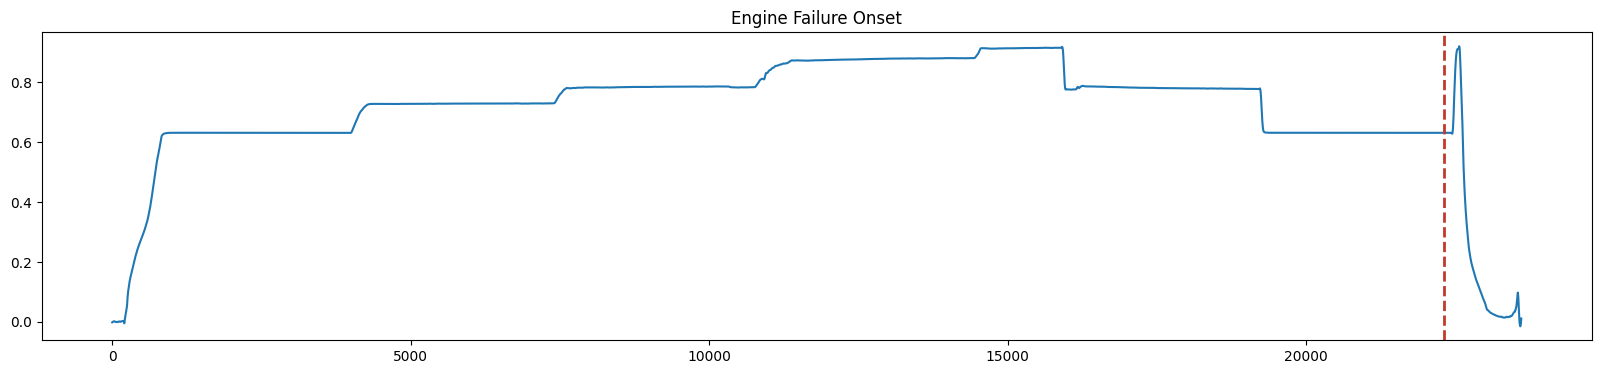

In [16]:
# fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
plt.figure(figsize=(20, 4))
plt.plot(df_fail.A1)
plt.axvline(22300, color=RED, lw=2.0, ls='--')
plt.title('Engine Failure Onset')

## 9 — Failure Event Visualisation

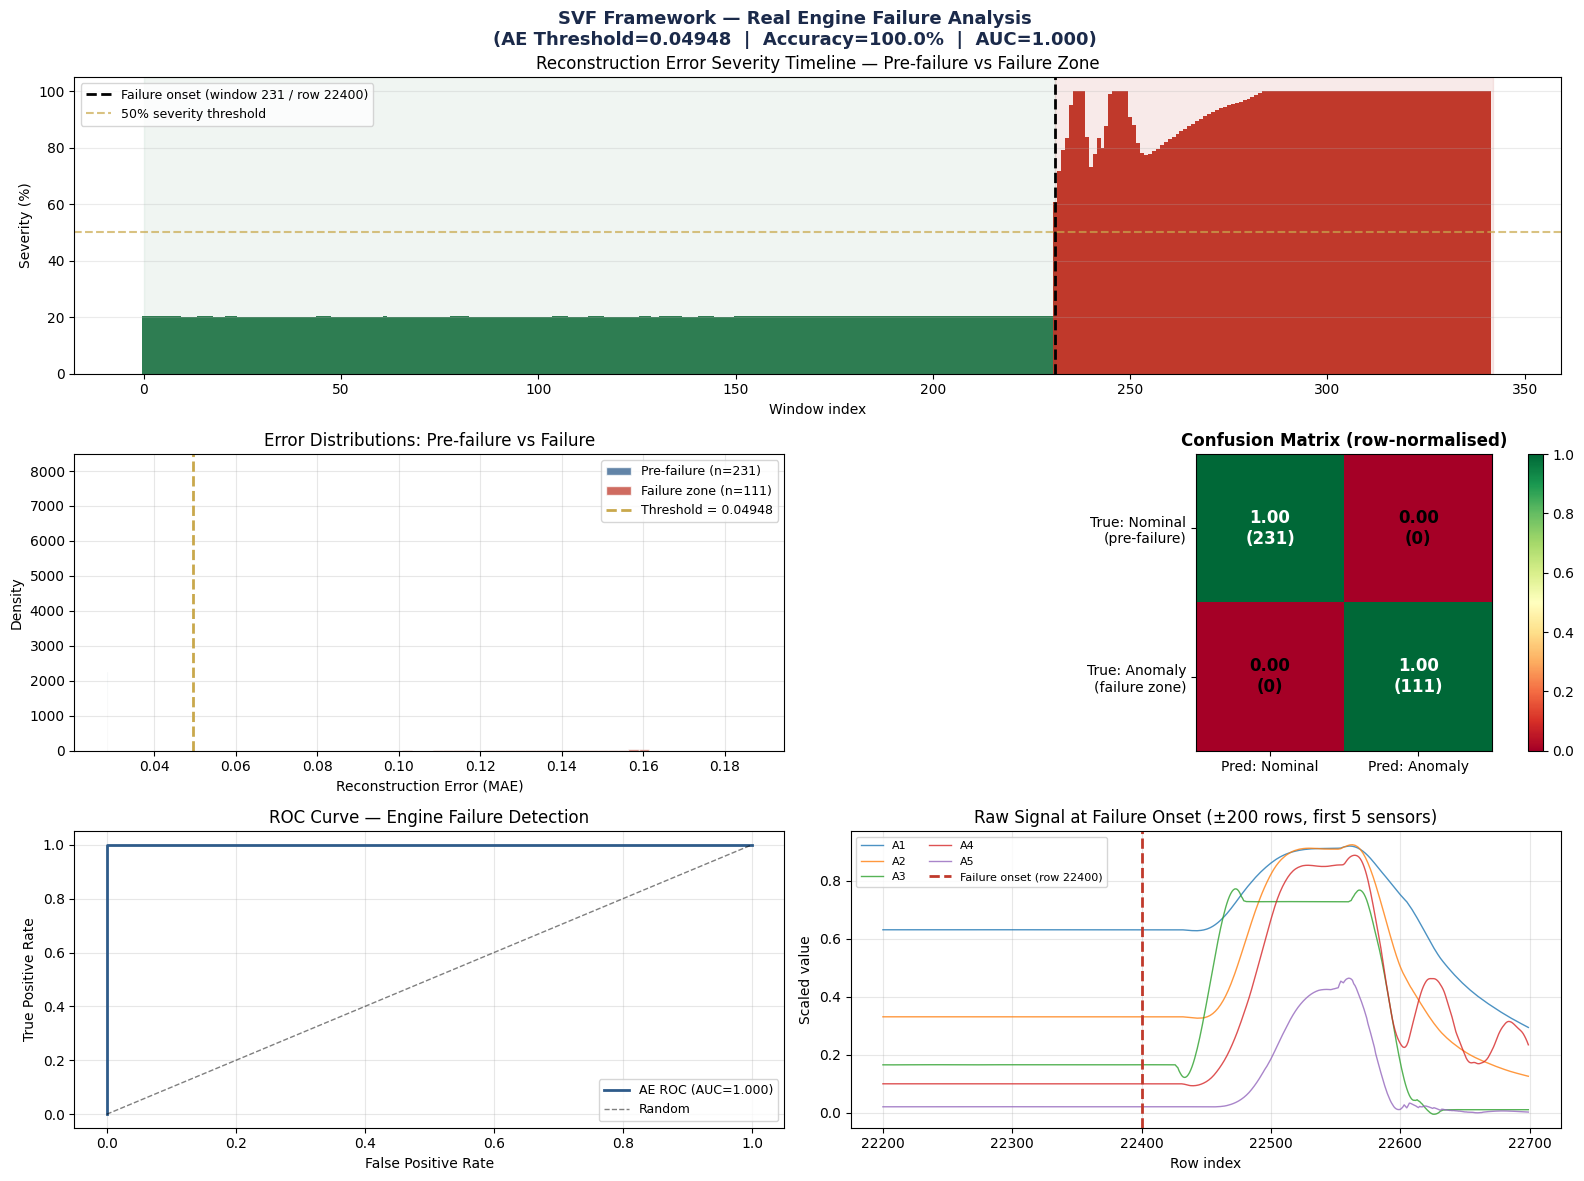

Saved: ../plots/nb5_engine_failure_analysis.png


In [17]:
n_pre_windows = len(X_pre)
timeline      = np.arange(len(X_test_fail))
severity_pct  = np.clip(fail_errors / (5 * nom_errors.mean()) * 100, 0, 100)

fig = plt.figure(figsize=(16, 12))
fig.suptitle('SVF Framework — Real Engine Failure Analysis\n'
             f'(AE Threshold={AE_THRESHOLD:.5f}  |  Accuracy={acc*100:.1f}%  |  '
             f'AUC={auc:.3f})',
             fontsize=13, fontweight='bold', color=NAVY)

# ── Panel 1: Severity timeline ────────────────────────────────────────────────
ax1 = fig.add_subplot(3, 1, 1)
colors_timeline = [GREEN if (e <= AE_THRESHOLD and l==0) else
                   RED   if (e >  AE_THRESHOLD and l==1) else
                   GOLD  for e, l in zip(fail_errors, y_test_fail)]
ax1.bar(timeline, severity_pct, color=colors_timeline, width=1.0)
ax1.axvline(n_pre_windows, color='black', lw=2.0, ls='--',
            label=f'Failure onset (window {n_pre_windows} / row {FAILURE_ONSET})')
ax1.axhline(50, color=GOLD, lw=1.5, ls='--', alpha=0.7, label='50% severity threshold')
ax1.set_xlabel('Window index'); ax1.set_ylabel('Severity (%)')
ax1.set_title('Reconstruction Error Severity Timeline — Pre-failure vs Failure Zone')
ax1.legend(fontsize=9); ax1.grid(axis='y', alpha=0.25)
ax1.set_ylim(0, 105)

# Shade zones
ax1.axvspan(0, n_pre_windows, alpha=0.07, color=GREEN, label='Pre-failure (Nominal)')
ax1.axvspan(n_pre_windows, len(timeline), alpha=0.10, color=RED,   label='Failure zone')

# ── Panel 2: Reconstruction error distribution ─────────────────────────────────
ax2 = fig.add_subplot(3, 2, 3)
ax2.hist(fail_errors[y_test_fail==0], bins=40, alpha=0.75, color=STEEL,
         label=f'Pre-failure (n={len(X_pre)})', density=True, edgecolor='white')
ax2.hist(fail_errors[y_test_fail==1], bins=40, alpha=0.75, color=RED,
         label=f'Failure zone (n={len(X_failure)})', density=True, edgecolor='white')
ax2.axvline(AE_THRESHOLD, color=GOLD, lw=2.0, ls='--',
            label=f'Threshold = {AE_THRESHOLD:.5f}')
ax2.set_xlabel('Reconstruction Error (MAE)'); ax2.set_ylabel('Density')
ax2.set_title('Error Distributions: Pre-failure vs Failure')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

# ── Panel 3: Confusion matrix ────────────────────────────────────────────────
ax3 = fig.add_subplot(3, 2, 4)
im = ax3.imshow(cm_fail_norm, cmap='RdYlGn', vmin=0, vmax=1)
ax3.set_xticks([0,1]); ax3.set_yticks([0,1])
ax3.set_xticklabels(['Pred: Nominal','Pred: Anomaly'], fontsize=10)
ax3.set_yticklabels(['True: Nominal\n(pre-failure)','True: Anomaly\n(failure zone)'], fontsize=10)
ax3.set_title('Confusion Matrix (row-normalised)', fontweight='bold')
for i,j in itertools.product(range(2),range(2)):
    ax3.text(j, i, f'{cm_fail_norm[i,j]:.2f}\n({cm_fail[i,j]})',
             ha='center', va='center', fontsize=12, fontweight='bold',
             color='white' if cm_fail_norm[i,j]>0.6 else 'black')
plt.colorbar(im, ax=ax3, fraction=0.046)

# ── Panel 4: ROC curve ───────────────────────────────────────────────────────
if has_both:
    ax4 = fig.add_subplot(3, 2, 5)
    fpr_f, tpr_f, _ = roc_curve(y_test_fail, fail_errors)
    ax4.plot(fpr_f, tpr_f, color=STEEL, lw=2.0, label=f'AE ROC (AUC={auc:.3f})')
    ax4.plot([0,1],[0,1],'k--',lw=1.0,alpha=0.5,label='Random')
    ax4.set_xlabel('False Positive Rate'); ax4.set_ylabel('True Positive Rate')
    ax4.set_title('ROC Curve — Engine Failure Detection')
    ax4.legend(fontsize=9); ax4.grid(alpha=0.3)

# ── Panel 5: Raw signal at failure onset ─────────────────────────────────────
ax5 = fig.add_subplot(3, 2, 6)
onset_row    = FAILURE_ONSET
plot_range   = range(max(0, onset_row-200), min(len(signal_full), onset_row+300))
for si in range(min(5, signal_full.shape[1])):
    ax5.plot(list(plot_range), signal_full[list(plot_range), si],
             lw=1.0, alpha=0.8,
             label=sensor_cols[si] if si < len(sensor_cols) else f'A{si}')
ax5.axvline(onset_row, color=RED, lw=2.0, ls='--', label=f'Failure onset (row {onset_row})')
ax5.set_xlabel('Row index'); ax5.set_ylabel('Scaled value')
ax5.set_title('Raw Signal at Failure Onset (±200 rows, first 5 sensors)')
ax5.legend(fontsize=8, ncol=2); ax5.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/nb5_engine_failure_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {PLOT_DIR}/nb5_engine_failure_analysis.png')


## 10 — Final Summary

In [18]:
print()
print('╔' + '═'*60 + '╗')
print(f'║  {"NB5 — COMPLETE RESULTS SUMMARY":^54}  ')
print('╠' + '═'*60 + '╣')
print(f'║  Model: BiLSTM (best classifier, {N_FAULT_TYPES}-class){" ":>19}')
print(f'║  AE Threshold (P95): {AE_THRESHOLD:.6f}{" ":>30}')
print('╠' + '═'*60 + '╣')

# Controlled test accuracy
n_total   = len(all_results)
ae_ok     = sum(1 for r in all_results
                if (r['true_label']==0 and not r['stage1']['is_anomaly']) or
                   (r['true_label']!=0 and r['stage1']['is_anomaly']))
clf_total = sum(1 for r in all_results if r['true_label']!=0 and r['stage2'] is not None)
clf_ok    = sum(1 for r in all_results
                if r['true_label']!=0 and r['stage2'] is not None
                and r['true_label']==r['stage2']['fault_type'])

print(f'║  PART 1 — CONTROLLED FAULT TESTING{" ":>22}')
print(f'║    Scenarios         : {n_total}{" ":>37}')
print(f'║    AE Detection      : {ae_ok}/{n_total} ({ae_ok/n_total*100:.0f}%){" ":>32}')
if clf_total > 0:
    print(f'║    Classification    : {clf_ok}/{clf_total} ({clf_ok/clf_total*100:.0f}% on faulty scenarios){" ":>18}')
print('╠' + '═'*60 + '╣')
print(f'║  PART 2 — ENGINE FAILURE ANALYSIS{" ":>24}')
print(f'║    Pre-failure windows : {len(X_pre):,}{" ":>34}')
print(f'║    Failure windows     : {len(X_failure):,}{" ":>34}')
print(f'║    Detection accuracy  : {acc*100:.1f}%{" ":>35}')
if has_both:
    print(f'║    ROC-AUC             : {auc:.4f}{" ":>34}')
print('╚' + '═'*60 + '╝')
print('\n✓ NB5 complete.')



╔════════════════════════════════════════════════════════════╗
║              NB5 — COMPLETE RESULTS SUMMARY              
╠════════════════════════════════════════════════════════════╣
║  Model: BiLSTM (best classifier, 7-class)                   
║  AE Threshold (P95): 0.049481                              
╠════════════════════════════════════════════════════════════╣
║  PART 1 — CONTROLLED FAULT TESTING                      
║    Scenarios         : 7                                     
║    AE Detection      : 6/7 (86%)                                
║    Classification    : 4/5 (80% on faulty scenarios)                  
╠════════════════════════════════════════════════════════════╣
║  PART 2 — ENGINE FAILURE ANALYSIS                        
║    Pre-failure windows : 231                                  
║    Failure windows     : 111                                  
║    Detection accuracy  : 100.0%                                   
║    ROC-AUC             : 1.0000       